In [3]:
# install packages
%pip install -q kaggle pyarrow

from pathlib import Path
import shutil
import zipfile
import os
import subprocess
import sys

# create ~/.kaggle on Windows too
kaggle_dir = Path.home() / ".kaggle"
kaggle_dir.mkdir(exist_ok=True)

# put kaggle.json there
src = Path("kaggle.json")   # make sure kaggle.json is in your notebook folder
dst = kaggle_dir / "kaggle.json"
shutil.copy(src, dst)

print("Copied to:", dst)
print("Exists:", dst.exists())

# download competition files
download_dir = Path("optiver")
download_dir.mkdir(exist_ok=True)

subprocess.run(
    ["kaggle", "competitions", "download",
     "-c", "optiver-realized-volatility-prediction",
     "-p", str(download_dir)],
    check=True
)

# unzip
zip_path = download_dir / "optiver-realized-volatility-prediction.zip"
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(download_dir)

print("Done. Files in optiver:")
print(os.listdir(download_dir))

Note: you may need to restart the kernel to use updated packages.
Copied to: C:\Users\charl\.kaggle\kaggle.json
Exists: True
Done. Files in optiver:
['book_test.parquet', 'book_train.parquet', 'feature_table_debug.parquet', 'optiver-realized-volatility-prediction.zip', 'sample_submission.csv', 'test.csv', 'trade_test.parquet', 'trade_train.parquet', 'train.csv']


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score, average_precision_score, log_loss 
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from pathlib import Path
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance 
from sklearn.neural_network import MLPClassifier 


DATA_DIR = Path("optiver") 
OUTPUT_DIR = Path("output") 
(OUTPUT_DIR / "figures").mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "tables").mkdir(parents=True, exist_ok=True)
sid = 0  

book0 = pd.read_parquet(f"{DATA_DIR}/book_train.parquet/stock_id={sid}")
trade0 = pd.read_parquet(f"{DATA_DIR}/trade_train.parquet/stock_id={sid}")

print("BOOK columns:\n", list(book0.columns))
print("\nTRADE columns:\n", list(trade0.columns))

BOOK columns:
 ['time_id', 'seconds_in_bucket', 'bid_price1', 'ask_price1', 'bid_price2', 'ask_price2', 'bid_size1', 'ask_size1', 'bid_size2', 'ask_size2']

TRADE columns:
 ['time_id', 'seconds_in_bucket', 'price', 'size', 'order_count']


In [5]:

## Load the data and print available stock IDs 
def available_stock_ids(book_dir): 
    return sorted(
        int(p.name.split("=")[1])
        for p in book_dir.iterdir()
        if p.name.startswith("stock_id=")
    )

def load_stock_data(data_dir, stock_id): 
    book = pd.read_parquet(data_dir / "book_train.parquet" / f"stock_id={stock_id}")
    trade = pd.read_parquet(data_dir / "trade_train.parquet" / f"stock_id={stock_id}")
    return book, trade

stock_ids = available_stock_ids(DATA_DIR / "book_train.parquet")
print(f"{len(stock_ids)} stock IDs available")


112 stock IDs available


In [6]:
# create leakage safe labels, meaning we only use features from the past to predict the future
# so the model only sees the first half and then predicts where price goes later 
def create_labels(book, anchor_start=240, anchor_end=300, future_start=540, future_width=60):
    """Use [anchor_start, anchor_end) to summarize current mid and predict [future_start, future_start + future_width)."""
    b = book.copy()
    b["mid"] = (b["bid_price1"] + b["ask_price1"]) / 2.0

    curr_mid = (
        b[(b["seconds_in_bucket"] >= anchor_start) & (b["seconds_in_bucket"] < anchor_end)]
        .groupby("time_id")["mid"]
        .mean()
        .rename("curr_mid")
    )

    future_mid = (
        b[(b["seconds_in_bucket"] >= future_start) &
          (b["seconds_in_bucket"] < future_start + future_width)]
        .groupby("time_id")["mid"]
        .mean()
        .rename("future_mid")
    )

    labels = pd.concat([curr_mid, future_mid], axis=1).dropna()
    labels["delta"] = labels["future_mid"] - labels["curr_mid"]
    labels["rel_move"] = labels["delta"] / labels["curr_mid"]
    labels["raw_target"] = (labels["rel_move"] > 0).astype(int)
    return labels


##### feature engineering pt1 #########
# essentially turning messy market data into one clean row of numbers per time_id window, so taht the model can learn params 
# main idea -> order book tells what people are willing to buy/sell rn, trade data tells what actually got traded 
# then summarize both into features such as spread, buying vs selling pressure etc. 

# feature explanations -> personal notes: 
"""
- bid price 1 = highest price someone is willing to buy at rn 
- ask price 1 = lowest price someone is willing to sell at rn
- bid_size 1 = num of shares/contracts available at best bid 
- ask_size 1 = num of shares/contracts available at best ask 
- next levels (i.e. bid price 2, ask price 2) show the next best prices and sizes after the best level deeper in the book 
- mid price = midpoint between best bid and ask, often used as a reference price (i.e. (bid_price1 + ask_price1) / 2)
- spread = ask_price1 - bid_price1, shows how wide the gap is between buy and sell prices, can indicate liquidity and transaction costs
           small spread -> more liquid and competitive, large -> less liquid and more uncertainty 
- depth = total quantity available at the best bid and best ask -> measures how much liquidity is stting at the top of the 
            large -> more size waiting near current market price, small -> prices may move more easily 
- denomintor for imbalance / WAP = total size at the best bid + best ask  
- Imbalance = measures if there is more size on buy size or sell size (usually)
- Weighted Average Price (WAP) = weighted price, adjusts the midpoint based on which side has more size 
- Obs = observation period -> avoids leakage 
"""
def create_book_features(book, obs_end=300, split_point=150): 
    """create the features needed for evaluation on the book"""
    b = book.copy()
    b["mid"] = (b["bid_price1"] + b["ask_price1"]) / 2
    b["spread1"] = b["ask_price1"] - b["bid_price1"]
    b["spread2"] = b["ask_price2"] - b["bid_price2"]
    b["depth1"] = b["bid_size1"] + b["ask_size1"]
    b["depth2"] = b["bid_size2"] + b["ask_size2"]

    denom1 = (b["bid_size1"] + b["ask_size1"]).replace(0, np.nan)
    b["imbalance1"] = (b["bid_size1"] - b["ask_size1"]) / denom1
    b["wap1"] = (b["bid_price1"] * b["ask_size1"] + b["ask_price1"] * b["bid_size1"]) / denom1
    b["rel_spread1"] = b["spread1"] / b["mid"].replace(0, np.nan)

    obs = b[b["seconds_in_bucket"] < obs_end].sort_values(["time_id", "seconds_in_bucket"])
    early = obs[obs["seconds_in_bucket"] < split_point]
    late = obs[obs["seconds_in_bucket"] >= split_point]

    stats = obs.groupby("time_id").agg(
        spread1_mean=("spread1", "mean"),
        spread1_std=("spread1", "std"),
        spread1_last=("spread1", "last"),
        spread2_mean=("spread2", "mean"),
        rel_spread1_mean=("rel_spread1", "mean"),
        mid_mean=("mid", "mean"),
        mid_std=("mid", "std"),
        mid_min=("mid", "min"),
        mid_max=("mid", "max"),
        wap1_mean=("wap1", "mean"),
        wap1_std=("wap1", "std"),
        imbalance1_mean=("imbalance1", "mean"),
        imbalance1_std=("imbalance1", "std"),
        depth1_mean=("depth1", "mean"),
        depth1_std=("depth1", "std"),
        depth2_mean=("depth2", "mean"),
        n_book_updates=("seconds_in_bucket", "count"),
        n_book_seconds=("seconds_in_bucket", "nunique")
    )

    early_stats = early.groupby("time_id").agg(
        spread1_early_mean=("spread1", "mean"),
        imbalance1_early_mean=("imbalance1", "mean"),
        depth1_early_mean=("depth1", "mean"),
        mid_early_mean=("mid", "mean"),
        rel_spread1_early_mean=("rel_spread1", "mean"),
    )

    late_stats = late.groupby("time_id").agg(
        spread1_late_mean=("spread1", "mean"),
        imbalance1_late_mean=("imbalance1", "mean"),
        depth1_late_mean=("depth1", "mean"),
        mid_late_mean=("mid", "mean"),
        rel_spread1_late_mean=("rel_spread1", "mean"),
    )

    # IMPORTANT: join them back into stats
    stats = stats.join(early_stats, how="left").join(late_stats, how="left")

    first_mid = obs.groupby("time_id")["mid"].first()
    last_mid = obs.groupby("time_id")["mid"].last()

    stats["obs_mid_return"] = (last_mid / first_mid) - 1
    stats["obs_mid_range"] = stats["mid_max"] - stats["mid_min"]
    stats["obs_vol_proxy"] = stats["mid_std"] / stats["mid_mean"]

    stats["spread1_shift"] = stats["spread1_late_mean"] - stats["spread1_early_mean"]
    stats["imbalance1_shift"] = stats["imbalance1_late_mean"] - stats["imbalance1_early_mean"]
    stats["depth1_shift"] = stats["depth1_late_mean"] - stats["depth1_early_mean"]
    stats["mid_shift"] = stats["mid_late_mean"] - stats["mid_early_mean"]
    stats["rel_spread1_shift"] = stats["rel_spread1_late_mean"] - stats["rel_spread1_early_mean"]

    return stats


def create_trade_features(trade_df, obs_end=300, split_point=150):
    """Create trade-based features for each time_id."""
    t = trade_df.copy()
    t["dollar_volume"] = t["price"] * t["size"]

    obs = t[t["seconds_in_bucket"] < obs_end].sort_values(["time_id", "seconds_in_bucket"])
    early = obs[obs["seconds_in_bucket"] < split_point]
    late = obs[obs["seconds_in_bucket"] >= split_point]

    features = obs.groupby("time_id").agg(
        total_volume=("size", "sum"),
        mean_trade_size=("size", "mean"),
        std_trade_size=("size", "std"),
        trade_count=("size", "count"),
        total_order_count=("order_count", "sum"),
        mean_trade_price=("price", "mean"),
        std_trade_price=("price", "std"),
        dollar_volume=("dollar_volume", "sum"),
        last_trade_price=("price", "last"),
        n_trade_seconds=("seconds_in_bucket", "nunique")
    )

    early_stats = early.groupby("time_id").agg(
        total_volume_early=("size", "sum"),
        trade_count_early=("size", "count"),
        mean_trade_size_early=("size", "mean"),
        dollar_volume_early=("dollar_volume", "sum"),
    )

    late_stats = late.groupby("time_id").agg(
        total_volume_late=("size", "sum"),
        trade_count_late=("size", "count"),
        mean_trade_size_late=("size", "mean"),
        dollar_volume_late=("dollar_volume", "sum"),
    )

    feats = features.join(early_stats, how="left").join(late_stats, how="left")
    feats["volume_per_trade"] = feats["total_volume"] / feats["trade_count"]
    feats["volume_shift"] = feats["total_volume_late"] - feats["total_volume_early"]
    feats["trade_count_shift"] = feats["trade_count_late"] - feats["trade_count_early"]
    feats["mean_trade_size_shift"] = feats["mean_trade_size_late"] - feats["mean_trade_size_early"]

    return feats



# Build the feature table for stock 
def build_features_table_for_one_stock(data_dir, stock_id, future_start=540, future_width=60):
    """Create the features table for training data"""
    book, trade = load_stock_data(data_dir, stock_id)

    labels = create_labels(book, future_start=future_start, future_width=future_width)
    book_features = create_book_features(book)
    trade_features = create_trade_features(trade)

    train_df = (
        book_features
        .join(trade_features, how="left")
        .join(labels, how="inner")
        .reset_index()
    )

    train_df["stock_id"] = stock_id
    trade_fill_cols = [
        "total_volume", "mean_trade_size", "std_trade_size", "trade_count",
        "total_order_count", "mean_trade_price", "std_trade_price", "dollar_volume",
        "last_trade_price", "n_trade_seconds", "volume_per_trade",
        "total_volume_early", "trade_count_early", "mean_trade_size_early", "dollar_volume_early",
        "total_volume_late", "trade_count_late", "mean_trade_size_late", "dollar_volume_late",
        "volume_shift", "trade_count_shift", "mean_trade_size_shift"
    ]

    existing_trade_fill_cols = list(dict.fromkeys(
        [c for c in trade_fill_cols if c in train_df.columns]
    ))

    train_df.loc[:, existing_trade_fill_cols] = train_df.loc[:, existing_trade_fill_cols].fillna(0)
    numeric_columns = train_df.select_dtypes(include=[np.number]).columns
    train_df[numeric_columns] = train_df[numeric_columns].replace([np.inf, -np.inf], np.nan)

    return train_df




def build_feature_table(data_dir, stock_ids=None, max_stocks=None, future_start=540, future_width=60):
    """create the table for multiple stocks"""
    if stock_ids is None:
        stock_ids = available_stock_ids(data_dir / "book_train.parquet")
    if max_stocks is not None:
        stock_ids = stock_ids[:max_stocks]

    frames = []

    for sid in stock_ids:
        print(f"Proceessing stock_id: {sid}")
        frames.append(
            build_features_table_for_one_stock(
                data_dir,
                sid,
                future_start=future_start,
                future_width=future_width
            )
        )

    full_train_df = pd.concat(frames, ignore_index=True)
    return full_train_df


## run debug build init 
df = build_feature_table(DATA_DIR, max_stocks=None) 
print(df.shape)
df.head() 

df.to_parquet(DATA_DIR / "feature_table_debug.parquet", index=False) 


Proceessing stock_id: 0
Proceessing stock_id: 1
Proceessing stock_id: 2
Proceessing stock_id: 3
Proceessing stock_id: 4
Proceessing stock_id: 5
Proceessing stock_id: 6
Proceessing stock_id: 7
Proceessing stock_id: 8
Proceessing stock_id: 9
Proceessing stock_id: 10
Proceessing stock_id: 11
Proceessing stock_id: 13
Proceessing stock_id: 14
Proceessing stock_id: 15
Proceessing stock_id: 16
Proceessing stock_id: 17
Proceessing stock_id: 18
Proceessing stock_id: 19
Proceessing stock_id: 20
Proceessing stock_id: 21
Proceessing stock_id: 22
Proceessing stock_id: 23
Proceessing stock_id: 26
Proceessing stock_id: 27
Proceessing stock_id: 28
Proceessing stock_id: 29
Proceessing stock_id: 30
Proceessing stock_id: 31
Proceessing stock_id: 32
Proceessing stock_id: 33
Proceessing stock_id: 34
Proceessing stock_id: 35
Proceessing stock_id: 36
Proceessing stock_id: 37
Proceessing stock_id: 38
Proceessing stock_id: 39
Proceessing stock_id: 40
Proceessing stock_id: 41
Proceessing stock_id: 42
Proceessin

In [9]:

# split first, then create filtered target later
def make_split(df, group_col="time_id", test_size=0.2, random_state=42):
    splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(splitter.split(df, groups=df[group_col]))

    train_df = df.iloc[train_idx].copy()
    test_df = df.iloc[test_idx].copy()

    return train_df, test_df

train_df, test_df = make_split(df)

print("Before filtering:")
print("train shape:", train_df.shape)
print("test shape:", test_df.shape)

# choose threshold from train ONLY
move_threshold = train_df["rel_move"].abs().quantile(0.33)
print("move threshold:", move_threshold)

# remove tiny moves from both sets using the same threshold
train_df = train_df[train_df["rel_move"].abs() > move_threshold].copy()
test_df = test_df[test_df["rel_move"].abs() > move_threshold].copy()

# now create final binary target
train_df["target"] = (train_df["rel_move"] > 0).astype(int)
test_df["target"] = (test_df["rel_move"] > 0).astype(int)

print("\nAfter filtering:")
print("train shape:", train_df.shape)
print("test shape:", test_df.shape)

print("\ntrain target balance:")
print(train_df["target"].value_counts(normalize=True).sort_index())

print("\ntest target balance:")
print(test_df["target"].value_counts(normalize=True).sort_index())

Before filtering:
train shape: (343069, 65)
test shape: (85766, 65)
move threshold: 0.0005584900267422199

After filtering:
train shape: (229856, 66)
test shape: (57342, 66)

train target balance:
target
0    0.492513
1    0.507487
Name: proportion, dtype: float64

test target balance:
target
0    0.499215
1    0.500785
Name: proportion, dtype: float64


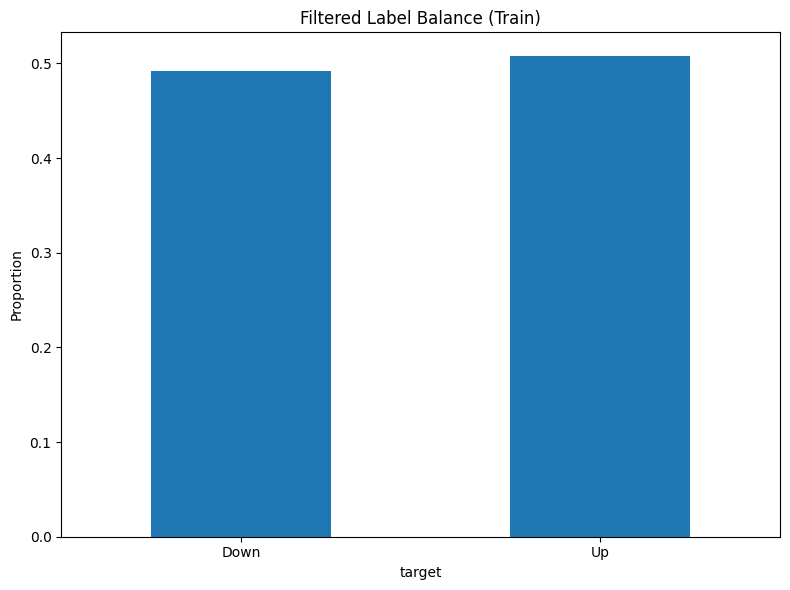

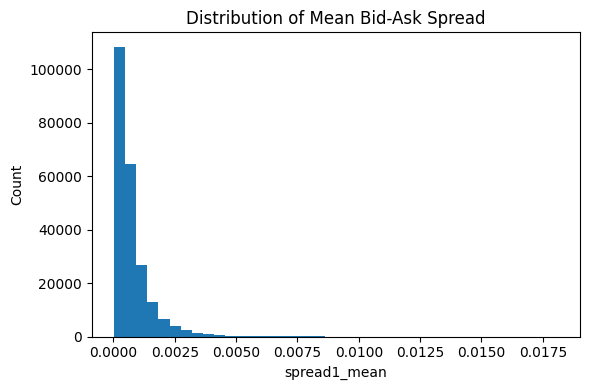

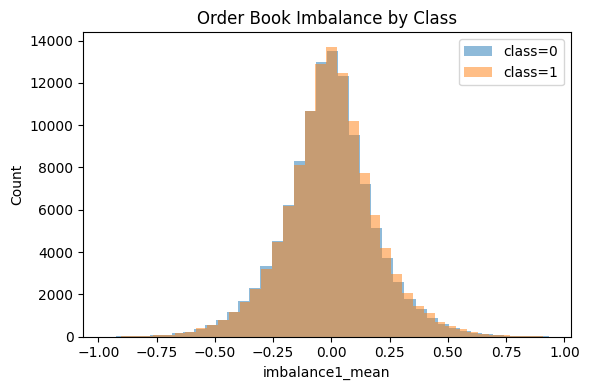

In [18]:
plt.figure(figsize=(8, 6))
train_df["target"].value_counts(normalize=True).sort_index().plot(kind="bar")
plt.xticks([0, 1], ["Down", "Up"], rotation=0)
plt.ylabel("Proportion")
plt.title("Filtered Label Balance (Train)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figures" / "filtered_label_balance.png")
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(train_df["spread1_mean"].dropna(), bins=40)
plt.title("Distribution of Mean Bid-Ask Spread")
plt.xlabel("spread1_mean")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figures" / "spread_hist.png")
plt.show()

plt.figure(figsize=(6, 4))
for cls in [0, 1]:
    subset = train_df.loc[train_df["target"] == cls, "imbalance1_mean"].dropna()
    plt.hist(subset, bins=40, alpha=0.5, label=f"class={cls}")
plt.legend()
plt.title("Order Book Imbalance by Class")
plt.xlabel("imbalance1_mean")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figures" / "imbalance_by_class.png")
plt.show()


In [10]:
METRIC_COLUMNS = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "balanced_accuracy",
    "average_precision",
    "log_loss",
    "specificity",
]

DROP_COLS = ["target", "raw_target", "delta", "rel_move", "curr_mid", "future_mid", "time_id"]


def make_onehot_encoder(dense=False):
    if dense:
        try:
            return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
        except TypeError:
            return OneHotEncoder(handle_unknown="ignore", sparse=False)
    return OneHotEncoder(handle_unknown="ignore")


def build_models(train_df, test_df, feature_cols=None):
    if feature_cols is None:
        feature_cols = [c for c in train_df.columns if c not in DROP_COLS]

    feature_cols = [c for c in feature_cols if c in train_df.columns]

    X_train = train_df[feature_cols].copy()
    y_train = train_df["target"].copy()

    X_test = test_df[feature_cols].copy()
    y_test = test_df["target"].copy()

    print("X_train shape:", X_train.shape)
    print("X_test shape:", X_test.shape)

    numeric_cols = [c for c in feature_cols if c != "stock_id"]
    categorical_cols = ["stock_id"] if "stock_id" in feature_cols else []

    linear_pre = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]),
                numeric_cols,
            ),
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", make_onehot_encoder(dense=False)),
                ]),
                categorical_cols,
            ),
        ]
    )

    tree_pre = ColumnTransformer(
        transformers=[
            ("num", SimpleImputer(strategy="median"), numeric_cols),
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", make_onehot_encoder(dense=False)),
                ]),
                categorical_cols,
            ),
        ]
    )

    dense_tree_pre = ColumnTransformer(
        transformers=[
            ("num", SimpleImputer(strategy="median"), numeric_cols),
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", make_onehot_encoder(dense=True)),
                ]),
                categorical_cols,
            ),
        ]
    )

    mlp_pre = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]),
                numeric_cols,
            ),
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", make_onehot_encoder(dense=True)),
                ]),
                categorical_cols,
            ),
        ]
    )

    models = {
        "dummy_majority": Pipeline([
            ("preprocess", tree_pre),
            ("model", DummyClassifier(strategy="most_frequent")),
        ]),
        "logistic_regression": Pipeline([
            ("preprocess", linear_pre),
            ("model", LogisticRegression(max_iter=3000, class_weight="balanced")),
        ]),
        "random_forest": Pipeline([
            ("preprocess", tree_pre),
            ("model", RandomForestClassifier(
                n_estimators=400,
                max_depth=14,
                min_samples_leaf=15,
                class_weight="balanced_subsample",
                n_jobs=-1,
                random_state=42,
            )),
        ]),
        "hist_gradient_boosting": Pipeline([
            ("preprocess", dense_tree_pre),
            ("model", HistGradientBoostingClassifier(
                learning_rate=0.05,
                max_depth=6,
                max_iter=250,
                min_samples_leaf=50,
                random_state=42,
            )),
        ]),
        "mlp_classifier": Pipeline([
            ("preprocess", mlp_pre),
            ("model", MLPClassifier(
                hidden_layer_sizes=(64, 32),
                alpha=1e-4,
                batch_size=1024,
                early_stopping=True,
                max_iter=50,
                n_iter_no_change=5,
                random_state=42,
            )),
        ]),
    }

    return models, X_train, y_train, X_test, y_test, feature_cols


def get_model_scores(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        raw_scores = model.decision_function(X)
        return 1.0 / (1.0 + np.exp(-raw_scores))
    return None


def compute_metrics(y_true, y_pred, y_score=None):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    out = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "specificity": specificity,
    }

    if y_score is not None and pd.Series(y_true).nunique() == 2:
        y_score_clipped = np.clip(y_score, 1e-6, 1 - 1e-6)
        out["roc_auc"] = roc_auc_score(y_true, y_score)
        out["average_precision"] = average_precision_score(y_true, y_score)
        out["log_loss"] = log_loss(y_true, y_score_clipped, labels=[0, 1])
    else:
        out["roc_auc"] = np.nan
        out["average_precision"] = np.nan
        out["log_loss"] = np.nan

    return out


def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)

    train_score = get_model_scores(model, X_train)
    test_score = get_model_scores(model, X_test)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_metrics = compute_metrics(y_train, train_pred, train_score)
    test_metrics = compute_metrics(y_test, test_pred, test_score)

    return {
        "train_metrics": train_metrics,
        "test_metrics": test_metrics,
        "train_pred": train_pred,
        "test_pred": test_pred,
        "train_score": train_score,
        "test_score": test_score,
    }


models, X_train, y_train, X_test, y_test, feature_cols = build_models(train_df, test_df)

fitted_models = {}
evaluation_store = {}
base_rows = []

for name, model in models.items():
    eval_out = evaluate_model(model, X_train, y_train, X_test, y_test)
    fitted_models[name] = model
    evaluation_store[name] = eval_out

    base_rows.append({"model": name, "split": "train", **eval_out["train_metrics"]})
    base_rows.append({"model": name, "split": "test", **eval_out["test_metrics"]})

base_results_long = (
    pd.DataFrame(base_rows)
    .sort_values(["split", "roc_auc", "f1", "accuracy"], ascending=[True, False, False, False])
    .reset_index(drop=True)
)

current_results_wide = base_results_long.pivot(index="model", columns="split", values=METRIC_COLUMNS)
current_results_wide.columns = [f"{split}_{metric}" for metric, split in current_results_wide.columns]
current_results_wide = current_results_wide.reset_index()

model_comparison_table = (
    base_results_long[base_results_long["split"] == "test"]
    .sort_values(["roc_auc", "f1", "accuracy"], ascending=False)
    .reset_index(drop=True)
)

display(current_results_wide.round(4))
display(model_comparison_table.round(4))

base_results_long.to_csv(OUTPUT_DIR / "tables" / "current_results_long.csv", index=False)
current_results_wide.to_csv(OUTPUT_DIR / "tables" / "current_results_train_test_wide.csv", index=False)
model_comparison_table.to_csv(OUTPUT_DIR / "tables" / "final_model_comparison_table.csv", index=False)


X_train shape: (229856, 59)
X_test shape: (57342, 59)


,model,test_accuracy,train_accuracy,test_precision,train_precision,test_recall,train_recall,test_f1,train_f1,test_roc_auc,train_roc_auc,test_balanced_accuracy,train_balanced_accuracy,test_average_precision,train_average_precision,test_log_loss,train_log_loss,test_specificity,train_specificity
0,dummy_majority,0.5008,0.5075,0.5008,0.5075,1.0000,1.0000,0.6674,0.6733,0.5000,0.5000,0.5000,0.5000,0.5008,0.5075,6.8969,6.8043,0.0000,0.0000
1,hist_gradient_boosting,0.5753,0.5997,0.5725,0.6002,0.6000,0.6324,0.5859,0.6159,0.6074,0.6409,0.5753,0.5992,0.5964,0.6383,0.6750,0.6639,0.5506,0.5659
2,logistic_regression,0.5764,0.5786,0.5790,0.5865,0.5652,0.5750,0.5720,0.5807,0.6015,0.6060,0.5765,0.5786,0.5826,0.5978,0.6814,0.6795,0.5877,0.5823
3,mlp_classifier,0.5678,0.5850,0.5673,0.5899,0.5770,0.5976,0.5721,0.5937,0.5967,0.6192,0.5678,0.5848,0.5871,0.6154,0.6791,0.6704,0.5585,0.5720
4,random_forest,0.5623,0.6720,0.5637,0.6784,0.5575,0.6724,0.5606,0.6754,0.5911,0.7559,0.5624,0.6720,0.5817,0.7674,0.6825,0.6542,0.5672,0.6715


,model,split,accuracy,precision,recall,f1,balanced_accuracy,specificity,roc_auc,average_precision,log_loss
0,hist_gradient_boosting,test,0.5753,0.5725,0.6000,0.5859,0.5753,0.5506,0.6074,0.5964,0.6750
1,logistic_regression,test,0.5764,0.5790,0.5652,0.5720,0.5765,0.5877,0.6015,0.5826,0.6814
2,mlp_classifier,test,0.5678,0.5673,0.5770,0.5721,0.5678,0.5585,0.5967,0.5871,0.6791
3,random_forest,test,0.5623,0.5637,0.5575,0.5606,0.5624,0.5672,0.5911,0.5817,0.6825
4,dummy_majority,test,0.5008,0.5008,1.0000,0.6674,0.5000,0.0000,0.5000,0.5008,6.8969


In [11]:
TRADE_PREFIXES = (
    "total_volume",
    "mean_trade_size",
    "std_trade_size",
    "trade_count",
    "total_order_count",
    "mean_trade_price",
    "std_trade_price",
    "dollar_volume",
    "last_trade_price",
    "n_trade_seconds",
    "volume_per_trade",
    "volume_shift",
)

BOOK_PREFIXES = (
    "spread1",
    "spread2",
    "rel_spread1",
    "mid",
    "wap1",
    "imbalance1",
    "depth1",
    "depth2",
    "n_book",
    "obs_",
)

SHIFT_FEATURES = {
    "spread1_shift",
    "imbalance1_shift",
    "depth1_shift",
    "mid_shift",
    "rel_spread1_shift",
    "volume_shift",
    "trade_count_shift",
    "mean_trade_size_shift",
}


def is_trade_feature(col):
    return any(col.startswith(prefix) for prefix in TRADE_PREFIXES)


def is_book_feature(col):
    return any(col.startswith(prefix) for prefix in BOOK_PREFIXES)


def is_shift_feature(col):
    return col in SHIFT_FEATURES


def feature_group(col):
    if col == "stock_id":
        return "stock_id"
    if is_trade_feature(col):
        return "trade"
    if is_book_feature(col):
        return "book"
    return "other"


def build_feature_subsets(feature_cols):
    feature_cols = [c for c in feature_cols if c not in DROP_COLS]
    stock_cols = [c for c in feature_cols if c == "stock_id"]
    book_cols = [c for c in feature_cols if is_book_feature(c)]
    trade_cols = [c for c in feature_cols if is_trade_feature(c)]

    subsets = {
        "full": feature_cols,
        "book_only": book_cols + stock_cols,
        "trade_only": trade_cols + stock_cols,
        "without_shift_features": [c for c in feature_cols if not is_shift_feature(c)],
        "without_stock_id": [c for c in feature_cols if c != "stock_id"],
    }

    return {k: list(dict.fromkeys(v)) for k, v in subsets.items()}


def make_results_wide_table(results_long, id_cols=("model",), metric_cols=None):
    if metric_cols is None:
        metric_cols = METRIC_COLUMNS

    wide = results_long.pivot_table(
        index=list(id_cols),
        columns="split",
        values=metric_cols,
        aggfunc="first",
    )
    wide.columns = [f"{split}_{metric}" for metric, split in wide.columns]
    wide = wide.reset_index()
    return wide


def make_train_test_gap_table(results_long, id_cols=("model",), metric_cols=None):
    if metric_cols is None:
        metric_cols = METRIC_COLUMNS

    wide = results_long.pivot_table(
        index=list(id_cols),
        columns="split",
        values=metric_cols,
        aggfunc="first",
    )

    rows = []
    for idx, row in wide.iterrows():
        idx = idx if isinstance(idx, tuple) else (idx,)
        out = {col_name: col_value for col_name, col_value in zip(id_cols, idx)}

        for metric in metric_cols:
            train_val = row.get((metric, "train"), np.nan)
            test_val = row.get((metric, "test"), np.nan)
            out[f"train_{metric}"] = train_val
            out[f"test_{metric}"] = test_val
            out[f"gap_{metric}"] = train_val - test_val

        rows.append(out)

    gap_df = pd.DataFrame(rows)
    if "test_roc_auc" in gap_df.columns:
        gap_df = gap_df.sort_values(["test_roc_auc", "test_f1", "test_accuracy"], ascending=False).reset_index(drop=True)

    return gap_df


def build_confusion_matrix_table(y_true, y_pred, model_name, split_name):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    return pd.DataFrame([{
        "model": model_name,
        "split": split_name,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "specificity": tn / (tn + fp) if (tn + fp) > 0 else np.nan,
        "recall": tp / (tp + fn) if (tp + fn) > 0 else np.nan,
        "precision": tp / (tp + fp) if (tp + fp) > 0 else np.nan,
    }])


def plot_confusion_matrices(evaluation_store, y_true, model_names, split_name="test", save_path=None):
    model_names = list(model_names)
    n_models = len(model_names)
    ncols = min(2, n_models)
    nrows = int(np.ceil(n_models / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows))
    axes = np.atleast_1d(axes).ravel()

    cm_tables = []

    for ax, model_name in zip(axes, model_names):
        y_pred = evaluation_store[model_name][f"{split_name}_pred"]

        ConfusionMatrixDisplay.from_predictions(
            y_true,
            y_pred,
            display_labels=["Down", "Up"],
            cmap="Blues",
            colorbar=False,
            ax=ax,
        )
        ax.set_title(f"{model_name} ({split_name})")

        cm_tables.append(build_confusion_matrix_table(y_true, y_pred, model_name, split_name))

    for ax in axes[len(model_names):]:
        ax.axis("off")

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()

    return pd.concat(cm_tables, ignore_index=True)


In [13]:
def run_horizon_experiment(
    data_dir,
    future_start,
    future_width=60,
    stock_ids=None,
    max_stocks=None,
    test_size=0.2,
    random_state=42,
):
    df_h = build_feature_table(
        data_dir,
        stock_ids=stock_ids,
        max_stocks=max_stocks,
        future_start=future_start,
        future_width=future_width,
    )

    train_df_h, test_df_h = make_split(
        df_h,
        group_col="time_id",
        test_size=test_size,
        random_state=random_state,
    )

    move_threshold_h = train_df_h["rel_move"].abs().quantile(0.33)

    train_df_h = train_df_h[train_df_h["rel_move"].abs() > move_threshold_h].copy()
    test_df_h = test_df_h[test_df_h["rel_move"].abs() > move_threshold_h].copy()

    train_df_h["target"] = (train_df_h["rel_move"] > 0).astype(int)
    test_df_h["target"] = (test_df_h["rel_move"] > 0).astype(int)

    models_h, X_train_h, y_train_h, X_test_h, y_test_h, feature_cols_h = build_models(train_df_h, test_df_h)

    rows = []
    for name, model in models_h.items():
        eval_out = evaluate_model(model, X_train_h, y_train_h, X_test_h, y_test_h)

        rows.append({
            "model": name,
            "split": "train",
            "future_start": future_start,
            "future_width": future_width,
            "n_train": len(train_df_h),
            "n_test": len(test_df_h),
            "n_features": len(feature_cols_h),
            **eval_out["train_metrics"],
        })

        rows.append({
            "model": name,
            "split": "test",
            "future_start": future_start,
            "future_width": future_width,
            "n_train": len(train_df_h),
            "n_test": len(test_df_h),
            "n_features": len(feature_cols_h),
            **eval_out["test_metrics"],
        })

    return pd.DataFrame(rows)


def run_horizon_grid(
    data_dir,
    future_starts=None,
    future_widths=None,
    stock_ids=None,
    max_stocks=None,
    test_size=0.2,
    random_state=42,
):
    if future_starts is None:
        future_starts = [300, 330, 360, 420, 480, 540]
    if future_widths is None:
        future_widths = [30, 60, 90, 120]

    all_results = []

    for future_start in future_starts:
        for future_width in future_widths:
            print(f"Running future_start={future_start}, future_width={future_width}")
            all_results.append(
                run_horizon_experiment(
                    data_dir=data_dir,
                    future_start=future_start,
                    future_width=future_width,
                    stock_ids=stock_ids,
                    max_stocks=max_stocks,
                    test_size=test_size,
                    random_state=random_state,
                )
            )

    return pd.concat(all_results, ignore_index=True)


future_starts = [300]
future_widths = [30]

horizon_results_long = run_horizon_grid(
    DATA_DIR,
    future_starts=future_starts,
    future_widths=future_widths,
    max_stocks=None,
    test_size=0.2,
    random_state=42,
)

horizon_results_test = horizon_results_long[horizon_results_long["split"] == "test"].copy()

horizon_summary_table = (
    horizon_results_test
    .pivot_table(
        index=["future_start", "future_width"],
        columns="model",
        values=METRIC_COLUMNS,
        aggfunc="first",
    )
)
horizon_summary_table.columns = [f"{metric}_{model}" for metric, model in horizon_summary_table.columns]
horizon_summary_table = horizon_summary_table.reset_index().sort_values(["future_start", "future_width"]).reset_index(drop=True)

best_setting_table = (
    horizon_results_test
    .sort_values(["model", "roc_auc", "f1", "accuracy"], ascending=[True, False, False, False])
    .groupby("model", as_index=False)
    .first()
    .sort_values(["roc_auc", "f1", "accuracy"], ascending=False)
    .reset_index(drop=True)
)

horizon_gap_table = make_train_test_gap_table(
    horizon_results_long,
    id_cols=("future_start", "future_width", "model"),
    metric_cols=METRIC_COLUMNS,
)

display(best_setting_table.round(4))
display(horizon_summary_table.head(12).round(4))

horizon_results_long.to_csv(OUTPUT_DIR / "tables" / "horizon_results_long.csv", index=False)
horizon_summary_table.to_csv(OUTPUT_DIR / "tables" / "horizon_results_summary.csv", index=False)
best_setting_table.to_csv(OUTPUT_DIR / "tables" / "best_setting_table_per_model.csv", index=False)
horizon_gap_table.to_csv(OUTPUT_DIR / "tables" / "horizon_train_test_gap_table.csv", index=False)


Running future_start=300, future_width=30
Proceessing stock_id: 0
Proceessing stock_id: 1
Proceessing stock_id: 2
Proceessing stock_id: 3
Proceessing stock_id: 4
Proceessing stock_id: 5
Proceessing stock_id: 6
Proceessing stock_id: 7
Proceessing stock_id: 8
Proceessing stock_id: 9
Proceessing stock_id: 10
Proceessing stock_id: 11
Proceessing stock_id: 13
Proceessing stock_id: 14
Proceessing stock_id: 15
Proceessing stock_id: 16
Proceessing stock_id: 17
Proceessing stock_id: 18
Proceessing stock_id: 19
Proceessing stock_id: 20
Proceessing stock_id: 21
Proceessing stock_id: 22
Proceessing stock_id: 23
Proceessing stock_id: 26
Proceessing stock_id: 27
Proceessing stock_id: 28
Proceessing stock_id: 29
Proceessing stock_id: 30
Proceessing stock_id: 31
Proceessing stock_id: 32
Proceessing stock_id: 33
Proceessing stock_id: 34
Proceessing stock_id: 35
Proceessing stock_id: 36
Proceessing stock_id: 37
Proceessing stock_id: 38
Proceessing stock_id: 39
Proceessing stock_id: 40
Proceessing stock_

,model,split,future_start,future_width,n_train,n_test,n_features,accuracy,precision,recall,f1,balanced_accuracy,specificity,roc_auc,average_precision,log_loss
0,hist_gradient_boosting,test,300,30,229691,57510,59,0.7623,0.7571,0.7625,0.7598,0.7623,0.7620,0.8445,0.8405,0.4905
1,mlp_classifier,test,300,30,229691,57510,59,0.7601,0.7675,0.7366,0.7518,0.7598,0.7830,0.8438,0.8386,0.4890
2,logistic_regression,test,300,30,229691,57510,59,0.7617,0.7574,0.7602,0.7588,0.7617,0.7631,0.8266,0.8061,0.5382
3,random_forest,test,300,30,229691,57510,59,0.7140,0.7084,0.7139,0.7111,0.7140,0.7141,0.7988,0.7955,0.5849
4,dummy_majority,test,300,30,229691,57510,59,0.4931,0.4931,1.0000,0.6605,0.5000,0.0000,0.5000,0.4931,7.0036


,future_start,future_width,accuracy_dummy_majority,accuracy_hist_gradient_boosting,accuracy_logistic_regression,accuracy_mlp_classifier,accuracy_random_forest,average_precision_dummy_majority,average_precision_hist_gradient_boosting,average_precision_logistic_regression,...,roc_auc_dummy_majority,roc_auc_hist_gradient_boosting,roc_auc_logistic_regression,roc_auc_mlp_classifier,roc_auc_random_forest,specificity_dummy_majority,specificity_hist_gradient_boosting,specificity_logistic_regression,specificity_mlp_classifier,specificity_random_forest
0,300,30,0.4931,0.7623,0.7617,0.7601,0.714,0.4931,0.8405,0.8061,...,0.5,0.8445,0.8266,0.8438,0.7988,0.0,0.762,0.7631,0.783,0.7141


In [14]:
all_feature_cols = [c for c in df.columns if c not in DROP_COLS]
numeric_feature_cols = [c for c in all_feature_cols if c != "stock_id"]

feature_summary_table = pd.DataFrame({
    "feature": all_feature_cols,
    "dtype": df[all_feature_cols].dtypes.astype(str).values,
    "feature_group": [feature_group(c) for c in all_feature_cols],
    "is_shift_feature": [is_shift_feature(c) for c in all_feature_cols],
    "n_missing": df[all_feature_cols].isna().sum().values,
    "pct_missing": df[all_feature_cols].isna().mean().values,
}).sort_values(["feature_group", "feature"]).reset_index(drop=True)

missingness_summary_table = (
    feature_summary_table[["feature", "feature_group", "is_shift_feature", "dtype", "n_missing", "pct_missing"]]
    .sort_values(["pct_missing", "n_missing"], ascending=False)
    .reset_index(drop=True)
)

feature_group_counts_table = (
    feature_summary_table
    .groupby(["feature_group", "is_shift_feature"], as_index=False)
    .size()
    .rename(columns={"size": "n_features"})
    .sort_values(["feature_group", "is_shift_feature"])
    .reset_index(drop=True)
)

corr_matrix = df[numeric_feature_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

correlation_screen_table = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "abs_correlation"})
    .sort_values("abs_correlation", ascending=False)
    .reset_index(drop=True)
)
correlation_screen_table = correlation_screen_table[correlation_screen_table["abs_correlation"] >= 0.95].reset_index(drop=True)

dataset_stats_table = pd.DataFrame([
    {"stat": "n_rows_full_unfiltered", "value": len(df)},
    {"stat": "n_rows_train_filtered", "value": len(train_df)},
    {"stat": "n_rows_test_filtered", "value": len(test_df)},
    {"stat": "n_total_columns", "value": df.shape[1]},
    {"stat": "n_model_features", "value": len(all_feature_cols)},
    {"stat": "n_numeric_features", "value": len(numeric_feature_cols)},
    {"stat": "n_categorical_features", "value": int("stock_id" in all_feature_cols)},
    {"stat": "n_stocks", "value": df["stock_id"].nunique()},
    {"stat": "train_positive_rate", "value": train_df["target"].mean()},
    {"stat": "test_positive_rate", "value": test_df["target"].mean()},
    {"stat": "n_features_with_missing_values", "value": int((feature_summary_table["n_missing"] > 0).sum())},
    {"stat": "overall_feature_missing_pct", "value": df[all_feature_cols].isna().mean().mean()},
    {"stat": "max_feature_missing_pct", "value": feature_summary_table["pct_missing"].max()},
    {"stat": "n_book_features", "value": int((feature_summary_table["feature_group"] == "book").sum())},
    {"stat": "n_trade_features", "value": int((feature_summary_table["feature_group"] == "trade").sum())},
    {"stat": "n_shift_features", "value": int(feature_summary_table["is_shift_feature"].sum())},
    {"stat": "n_high_corr_pairs_abs_ge_0_95", "value": len(correlation_screen_table)},
])

display(dataset_stats_table)
display(feature_group_counts_table)
display(missingness_summary_table.head(20))
display(correlation_screen_table.head(20))

dataset_stats_table.to_csv(OUTPUT_DIR / "tables" / "dataset_statistics_table.csv", index=False)
feature_summary_table.to_csv(OUTPUT_DIR / "tables" / "feature_summary_table.csv", index=False)
feature_group_counts_table.to_csv(OUTPUT_DIR / "tables" / "feature_group_counts_table.csv", index=False)
missingness_summary_table.to_csv(OUTPUT_DIR / "tables" / "missingness_summary_table.csv", index=False)
correlation_screen_table.to_csv(OUTPUT_DIR / "tables" / "numeric_feature_correlation_screen.csv", index=False)


,stat,value
0,n_rows_full_unfiltered,428835.000000
1,n_rows_train_filtered,229856.000000
2,n_rows_test_filtered,57342.000000
3,n_total_columns,65.000000
4,n_model_features,59.000000
5,n_numeric_features,58.000000
6,n_categorical_features,1.000000
7,n_stocks,112.000000
8,train_positive_rate,0.507487
9,test_positive_rate,0.500785


,feature_group,is_shift_feature,n_features
0,book,False,31
1,book,True,5
2,stock_id,False,1
3,trade,False,19
4,trade,True,3


,feature,feature_group,is_shift_feature,dtype,n_missing,pct_missing
0,depth1_early_mean,book,False,float64,0,0.0
1,depth1_late_mean,book,False,float64,0,0.0
2,depth1_mean,book,False,float64,0,0.0
3,depth1_shift,book,True,float64,0,0.0
4,depth1_std,book,False,float64,0,0.0
5,depth2_mean,book,False,float64,0,0.0
6,imbalance1_early_mean,book,False,float64,0,0.0
7,imbalance1_late_mean,book,False,float64,0,0.0
8,imbalance1_mean,book,False,float64,0,0.0
9,imbalance1_shift,book,True,float64,0,0.0


,feature_1,feature_2,abs_correlation
0,trade_count,n_trade_seconds,1.000000
1,mean_trade_size,volume_per_trade,1.000000
2,n_book_updates,n_book_seconds,1.000000
3,total_volume_early,dollar_volume_early,0.999957
4,total_volume,dollar_volume,0.999951
5,spread1_early_mean,rel_spread1_early_mean,0.999943
6,total_volume_late,dollar_volume_late,0.999939
7,spread1_mean,rel_spread1_mean,0.999936
8,spread1_late_mean,rel_spread1_late_mean,0.999921
9,mid_std,obs_vol_proxy,0.999881


After evaluating the models using these future_starts (300, 330, 360, 420, 480, 540) and future_widths (30, 60, 90, 120)
The best performing was 300/30 -> as future starts increased the results worsened aside from at 330 which was better for RF, the same trend appears w/ future_widths. 

In [15]:
permutation_model_names = [
    "logistic_regression",
    "random_forest",
    "hist_gradient_boosting",
    "mlp_classifier",
]

perm_n = min(20000, len(X_test))
if len(X_test) > perm_n:
    X_test_perm = X_test.sample(n=perm_n, random_state=42)
    y_test_perm = y_test.loc[X_test_perm.index]
else:
    X_test_perm = X_test.copy()
    y_test_perm = y_test.copy()

permutation_tables = []

for model_name in permutation_model_names:
    print(f"Running permutation importance for {model_name}")
    perm = permutation_importance(
        fitted_models[model_name],
        X_test_perm,
        y_test_perm,
        n_repeats=5,
        random_state=42,
        scoring="f1",
    )

    perm_df = pd.DataFrame({
        "model": model_name,
        "feature": X_test_perm.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
        "feature_group": [feature_group(c) for c in X_test_perm.columns],
        "is_shift_feature": [is_shift_feature(c) for c in X_test_perm.columns],
    }).sort_values("importance_mean", ascending=False).reset_index(drop=True)

    permutation_tables.append(perm_df)
    perm_df.to_csv(OUTPUT_DIR / "tables" / f"permutation_importance_{model_name}.csv", index=False)

permutation_importance_table = pd.concat(permutation_tables, ignore_index=True)

permutation_top15_table = (
    permutation_importance_table
    .sort_values(["model", "importance_mean"], ascending=[True, False])
    .groupby("model", group_keys=False)
    .head(15)
    .reset_index(drop=True)
)

permutation_group_summary = (
    permutation_importance_table
    .groupby(["model", "feature_group"], as_index=False)["importance_mean"]
    .sum()
    .sort_values(["model", "importance_mean"], ascending=[True, False])
    .reset_index(drop=True)
)

logreg_feature_names = fitted_models["logistic_regression"].named_steps["preprocess"].get_feature_names_out()
logreg_coefs = fitted_models["logistic_regression"].named_steps["model"].coef_[0]
secondary_logreg_coefficients = (
    pd.DataFrame({
        "feature": logreg_feature_names,
        "coef": logreg_coefs,
        "abs_coef": np.abs(logreg_coefs),
    })
    .sort_values("abs_coef", ascending=False)
    .reset_index(drop=True)
)

rf_feature_names = fitted_models["random_forest"].named_steps["preprocess"].get_feature_names_out()
rf_importances = fitted_models["random_forest"].named_steps["model"].feature_importances_
secondary_rf_importance = (
    pd.DataFrame({
        "feature": rf_feature_names,
        "importance": rf_importances,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(permutation_top15_table.round(6))
display(permutation_group_summary.round(6))
display(secondary_logreg_coefficients.head(20).round(6))
display(secondary_rf_importance.head(20).round(6))

permutation_importance_table.to_csv(OUTPUT_DIR / "tables" / "permutation_importance_test_all_models.csv", index=False)
permutation_top15_table.to_csv(OUTPUT_DIR / "tables" / "permutation_importance_top15_table.csv", index=False)
permutation_group_summary.to_csv(OUTPUT_DIR / "tables" / "permutation_importance_group_summary.csv", index=False)
secondary_logreg_coefficients.to_csv(OUTPUT_DIR / "tables" / "secondary_logreg_coefficients.csv", index=False)
secondary_rf_importance.to_csv(OUTPUT_DIR / "tables" / "secondary_random_forest_importance.csv", index=False)


Running permutation importance for logistic_regression
Running permutation importance for random_forest
Running permutation importance for hist_gradient_boosting
Running permutation importance for mlp_classifier


,model,feature,importance_mean,importance_std,feature_group,is_shift_feature
0,hist_gradient_boosting,last_trade_price,0.076908,0.001670,trade,False
1,hist_gradient_boosting,mid_late_mean,0.056681,0.001483,book,False
2,hist_gradient_boosting,obs_mid_return,0.048499,0.001819,book,False
3,hist_gradient_boosting,mid_shift,0.023340,0.001590,book,True
4,hist_gradient_boosting,obs_vol_proxy,0.005326,0.001125,book,False
5,hist_gradient_boosting,mid_min,0.003518,0.000622,book,False
6,hist_gradient_boosting,wap1_mean,0.003290,0.000382,book,False
7,hist_gradient_boosting,wap1_std,0.002598,0.000571,book,False
8,hist_gradient_boosting,mid_std,0.002556,0.000334,book,False
9,hist_gradient_boosting,mean_trade_price,0.002532,0.000900,trade,False


,model,feature_group,importance_mean
0,hist_gradient_boosting,book,0.146296
1,hist_gradient_boosting,trade,0.074316
2,hist_gradient_boosting,stock_id,-0.000604
3,logistic_regression,book,0.188465
4,logistic_regression,trade,0.144877
5,logistic_regression,stock_id,0.005167
6,mlp_classifier,book,0.279022
7,mlp_classifier,trade,0.065118
8,mlp_classifier,stock_id,0.002423
9,random_forest,book,0.102098


,feature,coef,abs_coef
0,num__last_trade_price,4.312417,4.312417
1,num__mean_trade_price,-4.267844,4.267844
2,num__mid_shift,-0.416397,0.416397
3,num__obs_mid_return,0.254073,0.254073
4,cat__stock_id_31,-0.205693,0.205693
5,num__mid_std,-0.198151,0.198151
6,num__obs_vol_proxy,0.194826,0.194826
7,num__mid_mean,-0.146543,0.146543
8,cat__stock_id_69,0.137636,0.137636
9,num__mid_late_mean,-0.133550,0.133550


,feature,importance
0,num__obs_mid_return,0.096740
1,num__last_trade_price,0.075869
2,num__mid_late_mean,0.036072
3,num__mid_shift,0.032327
4,num__wap1_mean,0.023764
5,num__mid_mean,0.023336
6,num__mean_trade_price,0.021232
7,num__mid_early_mean,0.019657
8,num__mid_max,0.019464
9,num__mid_min,0.018638


In [16]:
ablation_source = best_setting_table[best_setting_table["model"] != "dummy_majority"].copy()
final_best_row = ablation_source.sort_values(["roc_auc", "f1", "accuracy"], ascending=False).iloc[0]

ablation_model_name = final_best_row["model"]
ablation_future_start = int(final_best_row["future_start"])
ablation_future_width = int(final_best_row["future_width"])

print(
    f"Ablation model: {ablation_model_name}, "
    f"future_start={ablation_future_start}, future_width={ablation_future_width}"
)

ablation_df = build_feature_table(
    DATA_DIR,
    future_start=ablation_future_start,
    future_width=ablation_future_width,
    max_stocks=None,
)

ablation_train_df, ablation_test_df = make_split(
    ablation_df,
    group_col="time_id",
    test_size=0.2,
    random_state=42,
)

ablation_move_threshold = ablation_train_df["rel_move"].abs().quantile(0.33)

ablation_train_df = ablation_train_df[ablation_train_df["rel_move"].abs() > ablation_move_threshold].copy()
ablation_test_df = ablation_test_df[ablation_test_df["rel_move"].abs() > ablation_move_threshold].copy()

ablation_train_df["target"] = (ablation_train_df["rel_move"] > 0).astype(int)
ablation_test_df["target"] = (ablation_test_df["rel_move"] > 0).astype(int)

ablation_all_feature_cols = [c for c in ablation_train_df.columns if c not in DROP_COLS]
ablation_feature_sets = build_feature_subsets(ablation_all_feature_cols)

ablation_rows = []

for ablation_name, ablation_cols in ablation_feature_sets.items():
    ablation_models, X_train_ab, y_train_ab, X_test_ab, y_test_ab, _ = build_models(
        ablation_train_df,
        ablation_test_df,
        feature_cols=ablation_cols,
    )

    ablation_eval = evaluate_model(
        ablation_models[ablation_model_name],
        X_train_ab,
        y_train_ab,
        X_test_ab,
        y_test_ab,
    )

    ablation_rows.append({
        "ablation": ablation_name,
        "model": ablation_model_name,
        "future_start": ablation_future_start,
        "future_width": ablation_future_width,
        "n_features": len(ablation_cols),
        **{f"train_{k}": v for k, v in ablation_eval["train_metrics"].items()},
        **{f"test_{k}": v for k, v in ablation_eval["test_metrics"].items()},
    })

ablation_results_table = pd.DataFrame(ablation_rows)

full_row = ablation_results_table.loc[ablation_results_table["ablation"] == "full"].iloc[0]
for metric in ["accuracy", "f1", "roc_auc", "balanced_accuracy", "average_precision"]:
    ablation_results_table[f"{metric}_drop_vs_full"] = full_row[f"test_{metric}"] - ablation_results_table[f"test_{metric}"]

ablation_order = ["full", "book_only", "trade_only", "without_shift_features", "without_stock_id"]
ablation_results_table["ablation"] = pd.Categorical(
    ablation_results_table["ablation"],
    categories=ablation_order,
    ordered=True,
)
ablation_results_table = ablation_results_table.sort_values("ablation").reset_index(drop=True)

display(ablation_results_table.round(4))
ablation_results_table.to_csv(OUTPUT_DIR / "tables" / "ablation_results_table.csv", index=False)


Ablation model: hist_gradient_boosting, future_start=300, future_width=30
Proceessing stock_id: 0
Proceessing stock_id: 1
Proceessing stock_id: 2
Proceessing stock_id: 3
Proceessing stock_id: 4
Proceessing stock_id: 5
Proceessing stock_id: 6
Proceessing stock_id: 7
Proceessing stock_id: 8
Proceessing stock_id: 9
Proceessing stock_id: 10
Proceessing stock_id: 11
Proceessing stock_id: 13
Proceessing stock_id: 14
Proceessing stock_id: 15
Proceessing stock_id: 16
Proceessing stock_id: 17
Proceessing stock_id: 18
Proceessing stock_id: 19
Proceessing stock_id: 20
Proceessing stock_id: 21
Proceessing stock_id: 22
Proceessing stock_id: 23
Proceessing stock_id: 26
Proceessing stock_id: 27
Proceessing stock_id: 28
Proceessing stock_id: 29
Proceessing stock_id: 30
Proceessing stock_id: 31
Proceessing stock_id: 32
Proceessing stock_id: 33
Proceessing stock_id: 34
Proceessing stock_id: 35
Proceessing stock_id: 36
Proceessing stock_id: 37
Proceessing stock_id: 38
Proceessing stock_id: 39
Proceessing

,ablation,model,future_start,future_width,n_features,train_accuracy,train_precision,train_recall,train_f1,train_balanced_accuracy,...,test_balanced_accuracy,test_specificity,test_roc_auc,test_average_precision,test_log_loss,accuracy_drop_vs_full,f1_drop_vs_full,roc_auc_drop_vs_full,balanced_accuracy_drop_vs_full,average_precision_drop_vs_full
0,full,hist_gradient_boosting,300,30,59,0.7689,0.7695,0.7714,0.7704,0.7689,...,0.7623,0.7620,0.8445,0.8405,0.4905,0.0000,0.0000,0.0000,0.0000,0.0000
1,book_only,hist_gradient_boosting,300,30,37,0.7222,0.7211,0.7296,0.7253,0.7221,...,0.7158,0.7120,0.7949,0.7900,0.5488,0.0465,0.0458,0.0496,0.0465,0.0505
2,trade_only,hist_gradient_boosting,300,30,23,0.7068,0.7061,0.7139,0.7100,0.7068,...,0.6993,0.6984,0.7814,0.7780,0.5617,0.0629,0.0631,0.0630,0.0629,0.0625
3,without_shift_features,hist_gradient_boosting,300,30,51,0.7654,0.7662,0.7675,0.7668,0.7654,...,0.7577,0.7599,0.8416,0.8382,0.4952,0.0045,0.0051,0.0028,0.0046,0.0024
4,without_stock_id,hist_gradient_boosting,300,30,58,0.7690,0.7694,0.7718,0.7706,0.7690,...,0.7625,0.7623,0.8445,0.8404,0.4905,-0.0003,-0.0003,-0.0000,-0.0003,0.0001


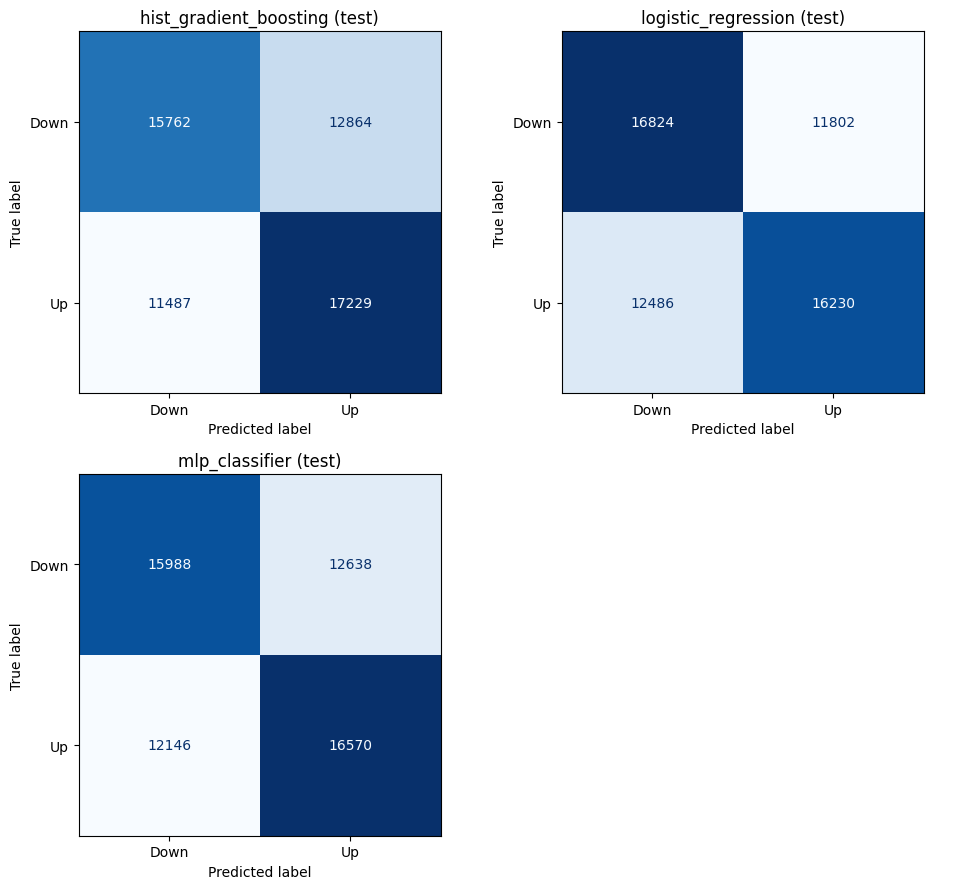

<Figure size 1000x600 with 0 Axes>

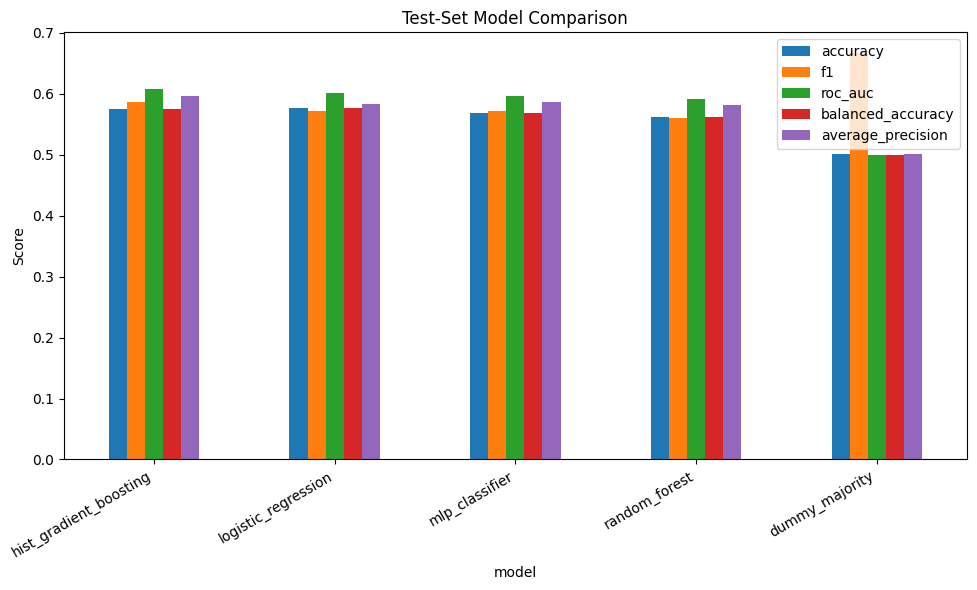

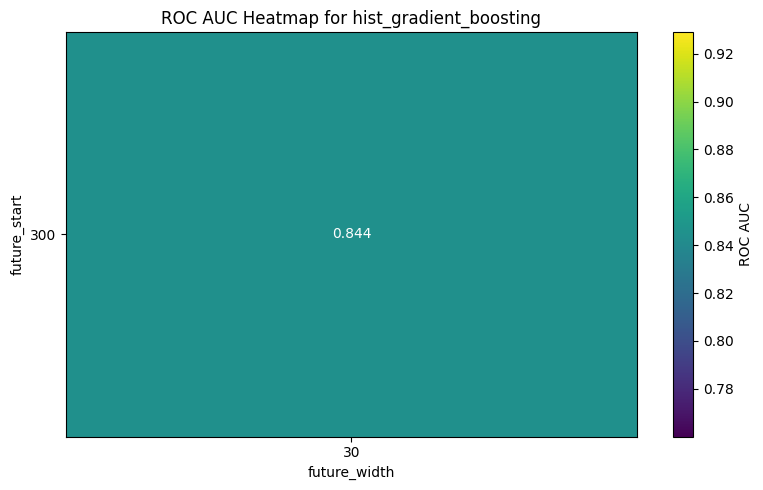

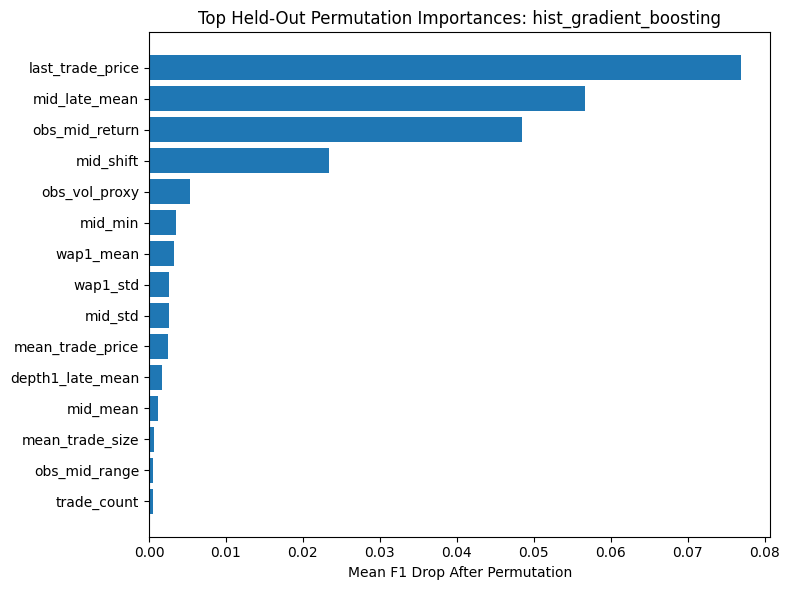

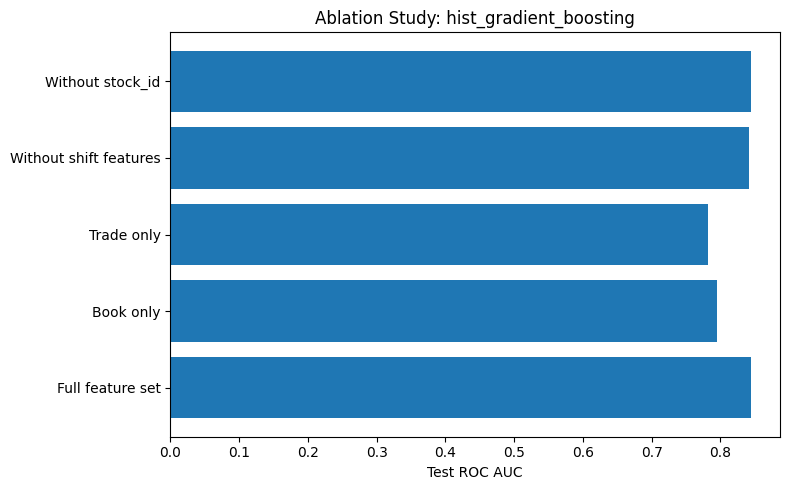

,model,split,accuracy,precision,recall,f1,balanced_accuracy,specificity,roc_auc,average_precision,log_loss
0,hist_gradient_boosting,test,0.5753,0.5725,0.6000,0.5859,0.5753,0.5506,0.6074,0.5964,0.6750
1,logistic_regression,test,0.5764,0.5790,0.5652,0.5720,0.5765,0.5877,0.6015,0.5826,0.6814
2,mlp_classifier,test,0.5678,0.5673,0.5770,0.5721,0.5678,0.5585,0.5967,0.5871,0.6791
3,random_forest,test,0.5623,0.5637,0.5575,0.5606,0.5624,0.5672,0.5911,0.5817,0.6825
4,dummy_majority,test,0.5008,0.5008,1.0000,0.6674,0.5000,0.0000,0.5000,0.5008,6.8969


,model,train_accuracy,test_accuracy,gap_accuracy,train_precision,test_precision,gap_precision,train_recall,test_recall,gap_recall,...,gap_balanced_accuracy,train_average_precision,test_average_precision,gap_average_precision,train_log_loss,test_log_loss,gap_log_loss,train_specificity,test_specificity,gap_specificity
0,hist_gradient_boosting,0.5997,0.5753,0.0243,0.6002,0.5725,0.0277,0.6324,0.6000,0.0324,...,0.0239,0.6383,0.5964,0.0420,0.6639,0.6750,-0.0111,0.5659,0.5506,0.0153
1,logistic_regression,0.5786,0.5764,0.0021,0.5865,0.5790,0.0075,0.5750,0.5652,0.0098,...,0.0022,0.5978,0.5826,0.0152,0.6795,0.6814,-0.0018,0.5823,0.5877,-0.0055
2,mlp_classifier,0.5850,0.5678,0.0172,0.5899,0.5673,0.0226,0.5976,0.5770,0.0206,...,0.0170,0.6154,0.5871,0.0282,0.6704,0.6791,-0.0087,0.5720,0.5585,0.0134
3,random_forest,0.6720,0.5623,0.1096,0.6784,0.5637,0.1147,0.6724,0.5575,0.1150,...,0.1096,0.7674,0.5817,0.1856,0.6542,0.6825,-0.0283,0.6715,0.5672,0.1043
4,dummy_majority,0.5075,0.5008,0.0067,0.5075,0.5008,0.0067,1.0000,1.0000,0.0000,...,0.0000,0.5075,0.5008,0.0067,6.8043,6.8969,-0.0926,0.0000,0.0000,0.0000


,model,split,future_start,future_width,n_train,n_test,n_features,accuracy,precision,recall,f1,balanced_accuracy,specificity,roc_auc,average_precision,log_loss
0,hist_gradient_boosting,test,300,30,229691,57510,59,0.7623,0.7571,0.7625,0.7598,0.7623,0.7620,0.8445,0.8405,0.4905
1,mlp_classifier,test,300,30,229691,57510,59,0.7601,0.7675,0.7366,0.7518,0.7598,0.7830,0.8438,0.8386,0.4890
2,logistic_regression,test,300,30,229691,57510,59,0.7617,0.7574,0.7602,0.7588,0.7617,0.7631,0.8266,0.8061,0.5382
3,random_forest,test,300,30,229691,57510,59,0.7140,0.7084,0.7139,0.7111,0.7140,0.7141,0.7988,0.7955,0.5849
4,dummy_majority,test,300,30,229691,57510,59,0.4931,0.4931,1.0000,0.6605,0.5000,0.0000,0.5000,0.4931,7.0036


,ablation,model,future_start,future_width,n_features,train_accuracy,train_precision,train_recall,train_f1,train_balanced_accuracy,...,test_balanced_accuracy,test_specificity,test_roc_auc,test_average_precision,test_log_loss,accuracy_drop_vs_full,f1_drop_vs_full,roc_auc_drop_vs_full,balanced_accuracy_drop_vs_full,average_precision_drop_vs_full
0,full,hist_gradient_boosting,300,30,59,0.7689,0.7695,0.7714,0.7704,0.7689,...,0.7623,0.7620,0.8445,0.8405,0.4905,0.0000,0.0000,0.0000,0.0000,0.0000
1,book_only,hist_gradient_boosting,300,30,37,0.7222,0.7211,0.7296,0.7253,0.7221,...,0.7158,0.7120,0.7949,0.7900,0.5488,0.0465,0.0458,0.0496,0.0465,0.0505
2,trade_only,hist_gradient_boosting,300,30,23,0.7068,0.7061,0.7139,0.7100,0.7068,...,0.6993,0.6984,0.7814,0.7780,0.5617,0.0629,0.0631,0.0630,0.0629,0.0625
3,without_shift_features,hist_gradient_boosting,300,30,51,0.7654,0.7662,0.7675,0.7668,0.7654,...,0.7577,0.7599,0.8416,0.8382,0.4952,0.0045,0.0051,0.0028,0.0046,0.0024
4,without_stock_id,hist_gradient_boosting,300,30,58,0.7690,0.7694,0.7718,0.7706,0.7690,...,0.7625,0.7623,0.8445,0.8404,0.4905,-0.0003,-0.0003,-0.0000,-0.0003,0.0001


In [17]:
final_results_wide = make_results_wide_table(base_results_long, id_cols=("model",), metric_cols=METRIC_COLUMNS)
train_test_gap_table = make_train_test_gap_table(base_results_long, id_cols=("model",), metric_cols=METRIC_COLUMNS)

top_models = model_comparison_table.head(3)["model"].tolist()
confusion_matrix_table = plot_confusion_matrices(
    evaluation_store=evaluation_store,
    y_true=y_test,
    model_names=top_models,
    split_name="test",
    save_path=OUTPUT_DIR / "figures" / "top_model_confusion_matrices.png",
)

best_non_dummy_model = best_setting_table[best_setting_table["model"] != "dummy_majority"].iloc[0]["model"]

plt.figure(figsize=(10, 6))
(
    model_comparison_table
    .set_index("model")[["accuracy", "f1", "roc_auc", "balanced_accuracy", "average_precision"]]
    .plot(kind="bar", figsize=(10, 6))
)
plt.title("Test-Set Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figures" / "model_comparison_bar.png", bbox_inches="tight")
plt.show()

horizon_heatmap = (
    horizon_results_test[horizon_results_test["model"] == best_non_dummy_model]
    .pivot(index="future_start", columns="future_width", values="roc_auc")
    .sort_index()
    .sort_index(axis=1)
)

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(horizon_heatmap.values, aspect="auto", cmap="viridis")

ax.set_xticks(range(len(horizon_heatmap.columns)))
ax.set_xticklabels(horizon_heatmap.columns)
ax.set_yticks(range(len(horizon_heatmap.index)))
ax.set_yticklabels(horizon_heatmap.index)
ax.set_xlabel("future_width")
ax.set_ylabel("future_start")
ax.set_title(f"ROC AUC Heatmap for {best_non_dummy_model}")

for i in range(horizon_heatmap.shape[0]):
    for j in range(horizon_heatmap.shape[1]):
        ax.text(j, i, f"{horizon_heatmap.iloc[i, j]:.3f}", ha="center", va="center", color="white")

fig.colorbar(im, ax=ax, label="ROC AUC")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figures" / "horizon_roc_auc_heatmap.png", bbox_inches="tight")
plt.show()

best_model_perm = (
    permutation_importance_table[permutation_importance_table["model"] == best_non_dummy_model]
    .sort_values("importance_mean", ascending=True)
    .tail(15)
)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(best_model_perm["feature"], best_model_perm["importance_mean"])
ax.set_title(f"Top Held-Out Permutation Importances: {best_non_dummy_model}")
ax.set_xlabel("Mean F1 Drop After Permutation")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figures" / "best_model_permutation_importance.png", bbox_inches="tight")
plt.show()

ablation_label_map = {
    "full": "Full feature set",
    "book_only": "Book only",
    "trade_only": "Trade only",
    "without_shift_features": "Without shift features",
    "without_stock_id": "Without stock_id",
}

ablation_plot_df = ablation_results_table.copy()
ablation_plot_df["ablation_label"] = ablation_plot_df["ablation"].astype(str).map(ablation_label_map)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(ablation_plot_df["ablation_label"], ablation_plot_df["test_roc_auc"])
ax.set_title(f"Ablation Study: {ablation_model_name}")
ax.set_xlabel("Test ROC AUC")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figures" / "ablation_roc_auc_bar.png", bbox_inches="tight")
plt.show()

final_results_wide.to_csv(OUTPUT_DIR / "tables" / "final_results_train_test_wide.csv", index=False)
train_test_gap_table.to_csv(OUTPUT_DIR / "tables" / "train_test_gap_table.csv", index=False)
confusion_matrix_table.to_csv(OUTPUT_DIR / "tables" / "confusion_matrix_table.csv", index=False)

display(model_comparison_table.round(4))
display(train_test_gap_table.round(4))
display(best_setting_table.round(4))
display(ablation_results_table.round(4))
